# 12. 앞당기려면 종목이 아니라 지수가 필요하다

> 2026-09-07 · 이동원 · 이슈 [#159](https://github.com/devlee328288/Alpha_Stack/issues/159) ·
> 결론 문서: [데이터파트 v3.9 변경사항](../../docs/데이터파트/version3.9/변경사항.md)

오준영 님이 KOSPI200 조합 E 와 개별종목 조합 F 를 연계할 때 **공통 OOS 첫 검증일이 `2014-02-17`
로 정해지는 이유**를 #159 에 적으셨습니다. 조합 E 의 `hv_regime` 이 250거래일 준비구간을 먹어
E 의 첫 사용 가능일이 `2011-01-27` 이 되고, 거기에 최소 학습 750 + gap 5 를 더하면 그 날이 됩니다.
그리고 *"앞당기려면 2010년 이전 HF 준비 데이터를 확보해야 한다"* 고 하셨습니다.

이 노트북은 그 숫자를 **먼저 그대로 재현**하고, 2010년 이전 자료를 **어느 원천에서 받을 수 있는지**
실측한 뒤, 받을 수 있는 것을 앞에 붙였을 때 **첫 검증일이 얼마나 앞당겨지는지**를 실제 로더와
실제 일정 함수로 잽니다.

순서:

1. 재현 — `2011-01-27` · `2014-02-17` · `2024-08-22`
2. 원천 — FDR 지수 · FDR 종목 · KRX Open API 에서 2008~2009 가 나오나
3. 이음새 — FDR 지수가 우리 KRX 값과 이어지나 (겹치는 닷새)
4. 준비구간 — 269거래일은 어디서 오나 · 최소 어디부터 받아야 하나
5. 공통 일정 — 지금 vs 지수 연장, 12폴드 각각

In [1]:
import inspect
import json
import re
import sqlite3
import sys
import time
from pathlib import Path

import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager, rc

ROOT = Path.cwd()
while not (ROOT / "supply").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import scripts.run_stock_model_experiment as exp                     # noqa: E402, I001
from features.model_dataset import build_model_dataset               # noqa: E402
from models.stock_ranking import build_common_validation_schedule    # noqa: E402

# 2026-09-07 반출본 (HF 에 올라간 것과 같은 파일).
OUTBOX = ROOT / "data" / "outbox" / "2026-09-07" / "full"
DB = ROOT / "data" / "krx_cache.db"
KOSPI200 = "코스피 200"
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# 한글 폰트 — 수업자료(09-finance-ml-dl)와 같은 방식.
rc("font", family=font_manager.FontProperties(
    fname="C:/Windows/Fonts/malgun.ttf").get_name())
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

t0 = time.time()
print("FinanceDataReader", fdr.__version__, "· python", sys.version.split()[0])
print("반출본:", OUTBOX)

FinanceDataReader 0.9.202 · python 3.12.13
반출본: C:\Users\kik32\workspace\EST-Camp-AI-Quant\team_project\Alpha_Stack\data\outbox\2026-09-07\full


## 1. 재현 — 오준영 님의 세 날짜

조합 E 데이터셋은 `features.model_dataset.build_model_dataset` 이, 개별종목 조합 F 는
`scripts.run_stock_model_experiment.load_stock_model_dataset` 이, 공통 일정은
`models.stock_ranking.build_common_validation_schedule` 이 만듭니다 — 전부 오준영 님 코드
그대로입니다. 로더는 HF 를 내려받은 자리(`data/raw/hf_snapshot`)를 보므로 반출본 자리로만 돌립니다.

In [2]:
index_prices = pd.read_parquet(OUTBOX / "index_price_dev.parquet")
k200 = index_prices.loc[index_prices["index_name"] == KOSPI200].sort_values("bas_dd")
print(f"반출본 KOSPI200 {len(k200):,}행 · {k200['bas_dd'].min()} ~ {k200['bas_dd'].max()}")

now_e = build_model_dataset(index_prices, "E", return_features=("five_day_return",)).frame
now_dates = now_e["bas_dd"].astype(str).drop_duplicates().sort_values()
print(f"조합 E 사용 가능 {len(now_dates):,}일 · 첫 {now_dates.min()} · 끝 {now_dates.max()}")

exp.DAILY_PATH = OUTBOX / "daily_price_dev.parquet"
exp.INDEX_PATH = OUTBOX / "index_price_dev.parquet"
combos_path = ROOT / "reports" / "stock_feature_combinations.json"
report = json.loads(combos_path.read_text(encoding="utf-8"))
winner = report["combination_winners"][0]
stock_features = tuple(report["combinations"][str(winner["combination"])]["features"])
t1 = time.time()
stock_frame = exp.load_stock_model_dataset(stock_features).frame
stock_dates = stock_frame["bas_dd"].astype(str).drop_duplicates().sort_values()
print(f"개별종목 조합 {winner['combination']} · {winner['model']} · {len(stock_frame):,}행 · "
      f"{len(stock_dates):,}일 · 첫 {stock_dates.min()} · 끝 {stock_dates.max()} "
      f"({time.time() - t1:.0f}s)")


def schedule_of(index_dates, stock_dates):
    sched = build_common_validation_schedule(index_dates.to_numpy(), stock_dates.to_numpy())
    common = pd.Index(index_dates).intersection(pd.Index(stock_dates)).sort_values()
    return sched, common


sched_now, common_now = schedule_of(now_dates, stock_dates)
print(f"공통 {len(common_now):,}일(첫 {common_now.min()}) · 첫 검증 {sched_now['bas_dd'].min()} · "
      f"마지막 {sched_now['bas_dd'].max()} · 검증 {len(sched_now)}일 · "
      f"1폴드 학습 {int((common_now < sched_now['bas_dd'].min()).sum()) - 5}일")
재현 = (now_dates.min(), sched_now["bas_dd"].min(), sched_now["bas_dd"].max()) == (
    "20110127", "20140217", "20240822")
print("오준영 님 값(2011-01-27 · 2014-02-17 · 2024-08-22) 재현:", "✅" if 재현 else "❌")

반출본 KOSPI200 3,618행 · 20100104 ~ 20240830


조합 E 사용 가능 3,343일 · 첫 20110127 · 끝 20240822


개별종목 조합 F · LightGBM · 174,412행 · 3,592일 · 첫 20100201 · 끝 20240822 (81s)
공통 3,343일(첫 20110127) · 첫 검증 20140217 · 마지막 20240822 · 검증 720일 · 1폴드 학습 750일
오준영 님 값(2011-01-27 · 2014-02-17 · 2024-08-22) 재현: ✅


## 2. 원천 — 2008~2009 가 어디서 나오나

세 원천에 같은 구간(2008-01-01 ~ 2009-12-31)을 물었습니다. KRX Open API 는 08-26 에 이미
`20091230 → 0행` 으로 실측돼 있어(`ingest/clients/krx_data.py` 머리) 여기서는 다시 치지 않습니다.

In [3]:
rows = []
for symbol, label in [("KS200", "KOSPI200 지수"), ("KS11", "KOSPI 지수"),
                      ("005930", "삼성전자"), ("000660", "SK하이닉스")]:
    frame = fdr.DataReader(symbol, "2008-01-01", "2009-12-31")
    rows.append({"기호": symbol, "무엇": label, "행": len(frame),
                 "첫날": frame.index.min().date() if len(frame) else None,
                 "끝날": frame.index.max().date() if len(frame) else None})
rows.append({"기호": "KRX Open API", "무엇": "우리 daily_price·index_price 원천", "행": 0,
             "첫날": None, "끝날": "08-26 실측 · 제공 구간이 2010-01-04 부터"})
원천 = pd.DataFrame(rows)
display(원천)

ks200_all = fdr.DataReader("KS200", "2000-01-01", "2010-01-31")
print(f"KS200 은 2000 년부터도 온다 — 2000-01-01 ~ 2010-01-31 {len(ks200_all):,}행 · "
      f"첫 {ks200_all.index.min().date()}")

# FDR 의 지수 경로는 종목 경로와 다르다 — 어디서 읽는지 코드에서 뽑아 본다.
from FinanceDataReader.krx.data import KrxIndexReaderCache  # noqa: E402

src = inspect.getsource(KrxIndexReaderCache)
url = re.search(r"https://[^'\"]+", src)
print("지수 캐시 URL 틀:", url.group(0) if url else "(못 찾음)")

,기호,무엇,행,첫날,끝날
0,KS200,KOSPI200 지수,501,2008-01-02,2009-12-30
1,KS11,KOSPI 지수,501,2008-01-02,2009-12-30
2,005930,삼성전자,0,None,None
3,000660,SK하이닉스,0,None,None
4,KRX Open API,우리 daily_price·index_price 원천,0,None,08-26 실측 · 제공 구간이 2010-01-04 부터


KS200 은 2000 년부터도 온다 — 2000-01-01 ~ 2010-01-31 2,490행 · 첫 2000-01-04
지수 캐시 URL 틀: https://raw.githubusercontent.com/FinanceData/fdr_krx_data_cache/refs/heads/master/data/index/year_{self.symbol}/{year}.csv


지수는 FinanceData 가 GitHub 에 올려 둔 **연도별 CSV 캐시**에서 옵니다. KRX 사이트를 직접 치는
경로가 아니라서, 업종 스냅샷 때 문제였던 KRX 약관(자동 수집 금지)과는 다른 길입니다. 다만 그
저장소에는 **LICENSE 파일이 없습니다**(2026-09-07 확인 · ★5). 지수값은 사실이라 저작권 대상이
아니라는 것이 통설이지만, 쓴다면 출처·받은 날·리비전을 대장에 남깁니다.

종목은 0행입니다 — 네이버 경로가 **최근 3,000거래일**만 주기 때문이고(품질 규약 §6), 이것은
FDR 로도 KRX Open API 로도 넘을 수 없습니다.

## 3. 이음새 — FDR 지수가 우리 값과 이어지나

같은 지수를 두 원천에서 받은 것이라 **겹치는 날은 같아야** 합니다. 2010-01-04 ~ 01-08 닷새를
종가·전일비·등락률까지 대조합니다. 칸 대응은 `Close→close · Comp→change ·
Change×100→change_rate · Volume→volume · Amount→value · MarCap→market_cap` 입니다.

In [4]:
overlap = fdr.DataReader("KS200", "2010-01-04", "2010-01-08")
ours = k200.loc[k200["bas_dd"].isin(overlap.index.strftime("%Y%m%d"))]
대조 = pd.DataFrame({
    "bas_dd": ours["bas_dd"].to_numpy(),
    "close(KRX)": ours["close"].to_numpy(), "Close(FDR)": overlap["Close"].to_numpy(),
    "change(KRX)": ours["change"].to_numpy(), "Comp(FDR)": overlap["Comp"].to_numpy(),
    "change_rate(KRX)": ours["change_rate"].to_numpy(),
    "Change×100(FDR)": (overlap["Change"] * 100).round(2).to_numpy(),
    "volume(KRX)": ours["volume"].to_numpy(), "Volume(FDR)": overlap["Volume"].to_numpy(),
})
대조["종가차"] = (대조["close(KRX)"] - 대조["Close(FDR)"]).abs()
대조["등락률차"] = (대조["change_rate(KRX)"] - 대조["Change×100(FDR)"]).abs()
display(대조)
print("닷새 전부 같은가 — 종가:", bool((대조["종가차"] == 0).all()),
      "· 전일비:", bool((대조["change(KRX)"] == 대조["Comp(FDR)"]).all()),
      "· 등락률:", bool((대조["등락률차"] == 0).all()),
      "· 거래량:", bool((대조["volume(KRX)"] == 대조["Volume(FDR)"]).all()))

,bas_dd,close(KRX),Close(FDR),change(KRX),Comp(FDR),change_rate(KRX),Change×100(FDR),volume(KRX),Volume(FDR),종가차,등락률차
0,20100104,223.49,223.49,1.63,1.63,0.73,0.73,85967328.0,85967328.0,0.0,0.0
1,20100105,222.84,222.84,-0.65,-0.65,-0.29,-0.29,153282171.0,153282171.0,0.0,0.0
2,20100106,224.67,224.67,1.83,1.83,0.82,0.82,170500363.0,170500363.0,0.0,0.0
3,20100107,221.31,221.31,-3.36,-3.36,-1.50,-1.50,183416926.0,183416926.0,0.0,0.0
4,20100108,222.66,222.66,1.35,1.35,0.61,0.61,157255197.0,157255197.0,0.0,0.0


닷새 전부 같은가 — 종가: True · 전일비: True · 등락률: True · 거래량: True


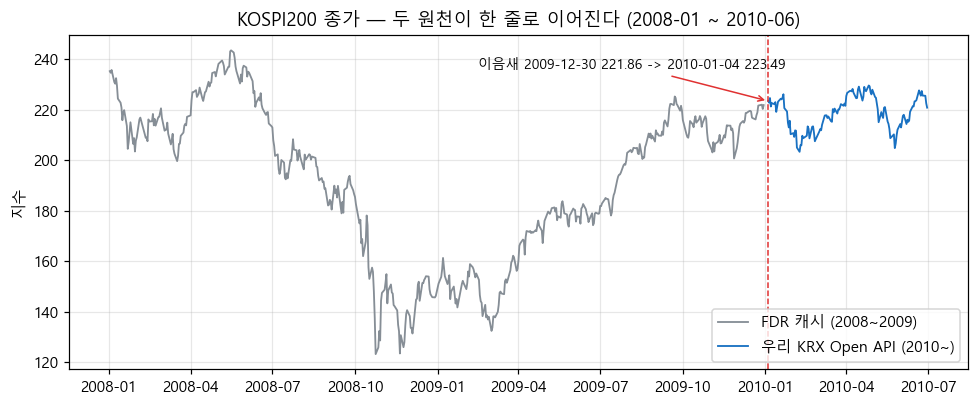

In [5]:
# 그림 1 — 이음새. FDR 로 받은 2008~2009 와 우리 KRX 2010~ 를 한 줄로 그린다.
fdr_pre = fdr.DataReader("KS200", "2008-01-01", "2009-12-31")["Close"]
sub = k200.loc[k200["bas_dd"] <= "20100630"]
ours_post = pd.Series(sub["close"].to_numpy(), index=pd.to_datetime(sub["bas_dd"]))
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(fdr_pre.index, fdr_pre.to_numpy(), color="#868e96", lw=1.2,
        label="FDR 캐시 (2008~2009)")
ax.plot(ours_post.index, ours_post.to_numpy(), color="#1971c2", lw=1.2,
        label="우리 KRX Open API (2010~)")
ax.axvline(pd.Timestamp("2010-01-04"), color="#e03131", ls="--", lw=1)
ax.annotate(f"이음새 2009-12-30 {fdr_pre.iloc[-1]:.2f} -> 2010-01-04 {ours_post.iloc[0]:.2f}",
            xy=(pd.Timestamp("2010-01-04"), ours_post.iloc[0]),
            xytext=(pd.Timestamp("2009-02-15"), 236), fontsize=9,
            arrowprops={"arrowstyle": "->", "color": "#e03131"})
ax.set_title("KOSPI200 종가 — 두 원천이 한 줄로 이어진다 (2008-01 ~ 2010-06)")
ax.set_ylabel("지수")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 4. 준비구간 — 269거래일은 어디서 오나

`hv_regime_t = hv_20_t / mean(hv_20_(t-249 .. t))` 입니다. `hv_20` 이 앞 20행을, 그 위의 250일
평균이 다시 249행을 먹어 **20 + 250 − 1 = 269** 거래일이 준비구간입니다. 조합 E 의 다른 피처
(`atr_ratio` · `bb_bandwidth`)는 그보다 짧아 병목이 아닙니다.

FDR 2008-01-02 ~ 2009-12-30 (501행)을 반출본 앞에 붙여 같은 함수로 다시 만들면 첫 사용 가능일이
어디까지 오는지, 그리고 **최소 어디부터** 있으면 종목 F(`2010-02-01`)가 병목이 되는지를 잽니다.

In [6]:
ext = fdr.DataReader("KS200", "2008-01-01", "2009-12-31")
붙일행 = pd.DataFrame({
    "bas_dd": ext.index.strftime("%Y%m%d"), "index_name": KOSPI200, "index_class": "KOSPI",
    "open": ext["Open"].to_numpy(), "high": ext["High"].to_numpy(), "low": ext["Low"].to_numpy(),
    "close": ext["Close"].to_numpy(), "change": ext["Comp"].to_numpy(),
    "change_rate": (ext["Change"] * 100).round(2).to_numpy(),
    "volume": ext["Volume"].to_numpy(dtype="float64"),
    "value": ext["Amount"].to_numpy(dtype="float64"),
    "market_cap": ext["MarCap"].to_numpy(dtype="float64"),
})
붙일행 = 붙일행[list(index_prices.columns)].astype(index_prices.dtypes.to_dict(), errors="ignore")
extended = pd.concat([붙일행, index_prices], ignore_index=True)
ext_e = build_model_dataset(extended, "E", return_features=("five_day_return",)).frame
ext_dates = ext_e["bas_dd"].astype(str).drop_duplicates().sort_values()

fdr_days = list(ext.index.strftime("%Y%m%d"))
warm = sum(1 for d in fdr_days if d < ext_dates.min())
with sqlite3.connect(DB) as con:
    cal = pd.read_sql("SELECT DISTINCT bas_dd FROM trading_calendar ORDER BY bas_dd", con)
cal = cal["bas_dd"].astype(str).tolist()
all_days = fdr_days + cal
최소시작 = all_days[all_days.index("20100201") - warm]
print(f"[늘림] 조합 E 사용 가능 {len(ext_dates):,}일 · 첫 {ext_dates.min()} "
      f"(지금 {now_dates.min()})")
print(f"준비구간 = {warm} 거래일 (hv_20 창 20 + regime 창 250 - 1)")
print(f"종목 F(20100201) 가 병목이 되려면 지수는 {최소시작} 부터 {warm} 거래일만 있으면 된다")
print(f"참고 — FDR 거래일 수: 2008 년 {sum(d.startswith('2008') for d in fdr_days)} · "
      f"2009 년 {sum(d.startswith('2009') for d in fdr_days)} · "
      f"우리 달력 distinct {len(cal):,}일 ({cal[0]} ~ {cal[-1]})")

[늘림] 조합 E 사용 가능 3,844일 · 첫 20090204 (지금 20110127)
준비구간 = 269 거래일 (hv_20 창 20 + regime 창 250 - 1)
종목 F(20100201) 가 병목이 되려면 지수는 20090108 부터 269 거래일만 있으면 된다
참고 — FDR 거래일 수: 2008 년 248 · 2009 년 253 · 우리 달력 distinct 4,105일 (20100104 ~ 20260904)


## 5. 공통 일정 — 지금 vs 지수 연장, 12폴드 각각

같은 `build_common_validation_schedule` 에 지수 날짜만 바꿔 넣습니다. 종목 날짜는 1절의 실제
로더 값 그대로입니다.

In [7]:
sched_ext, common_ext = schedule_of(ext_dates, stock_dates)
pos = {d: i for i, d in enumerate(cal)}


def fold_table(sched, label):
    g = sched.groupby("fold")["bas_dd"].agg(["min", "max", "count"])
    return g.rename(columns={"min": f"{label} 시작", "max": f"{label} 끝",
                             "count": f"{label} 일수"})


폴드 = fold_table(sched_now, "지금").join(fold_table(sched_ext, "연장"))
폴드["앞당김(거래일)"] = [
    pos[a] - pos[b] for a, b in zip(폴드["지금 시작"], 폴드["연장 시작"], strict=True)]
display(폴드)
print(f"공통 첫 날 {common_now.min()} -> {common_ext.min()} · "
      f"첫 검증일 {sched_now['bas_dd'].min()} -> {sched_ext['bas_dd'].min()} "
      f"({폴드['앞당김(거래일)'].iloc[0]} 거래일) · 마지막 검증일 {sched_now['bas_dd'].max()} -> "
      f"{sched_ext['bas_dd'].max()} · 검증 일수 {len(sched_now)} -> {len(sched_ext)}")

,지금 시작,지금 끝,지금 일수,연장 시작,연장 끝,연장 일수,앞당김(거래일)
fold,,,,,,,
1,20140217,20140514,60,20130212,20130508,60,249
2,20150123,20150421,60,20140220,20140519,60,227
3,20151228,20160328,60,20150305,20150601,60,204
4,20161202,20170228,60,20160311,20160608,60,181
5,20171113,20180207,60,20170320,20170616,60,158
6,20181024,20190118,60,20180402,20180629,60,136
7,20190930,20191224,60,20190416,20190711,60,113
8,20200902,20201130,60,20200422,20200717,60,91
9,20210806,20211105,60,20210430,20210726,60,68


공통 첫 날 20110127 -> 20100201 · 첫 검증일 20140217 -> 20130212 (249 거래일) · 마지막 검증일 20240822 -> 20240822 · 검증 일수 720 -> 720


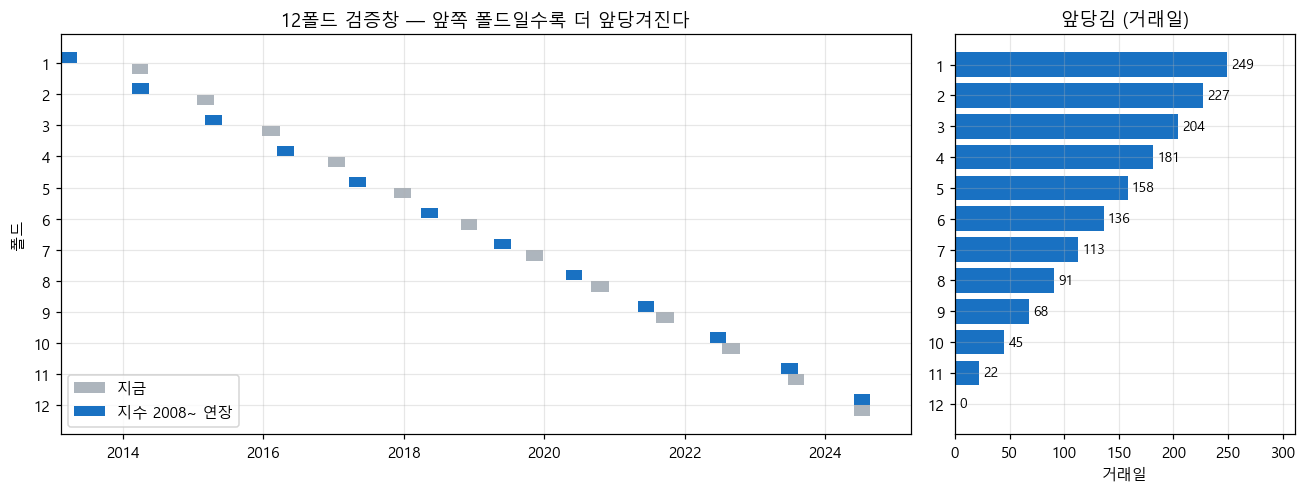

총 87s


In [8]:
# 그림 2 — 폴드별 검증창을 두 줄로 놓고, 앞당김을 옆에 세운다.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [3, 1.2]})
to_dt = lambda s: pd.to_datetime(s)  # noqa: E731
for fold, r in 폴드.iterrows():
    ax1.barh(fold + 0.18, (to_dt(r["지금 끝"]) - to_dt(r["지금 시작"])).days,
             left=to_dt(r["지금 시작"]), height=0.34, color="#adb5bd",
             label="지금" if fold == 1 else None)
    ax1.barh(fold - 0.18, (to_dt(r["연장 끝"]) - to_dt(r["연장 시작"])).days,
             left=to_dt(r["연장 시작"]), height=0.34, color="#1971c2",
             label="지수 2008~ 연장" if fold == 1 else None)
ax1.set_yticks(range(1, 13))
ax1.set_ylabel("폴드")
ax1.invert_yaxis()
ax1.set_title("12폴드 검증창 — 앞쪽 폴드일수록 더 앞당겨진다")
ax1.legend(loc="lower left")
bars = ax2.barh(폴드.index, 폴드["앞당김(거래일)"], color="#1971c2")
for b, v in zip(bars, 폴드["앞당김(거래일)"], strict=True):
    ax2.text(v + 4, b.get_y() + b.get_height() / 2, f"{v}", va="center", fontsize=9)
ax2.set_yticks(range(1, 13))
ax2.invert_yaxis()
ax2.set_xlim(0, 폴드["앞당김(거래일)"].max() * 1.25)
ax2.set_title("앞당김 (거래일)")
ax2.set_xlabel("거래일")
plt.tight_layout()
plt.show()
print(f"총 {time.time() - t0:.0f}s")

## 결론

| 물음 | 답 |
|---|---|
| 오준영 님 세 날짜는 재현되나 | ✅ `2011-01-27` · `2014-02-17` · `2024-08-22` 그대로 |
| 무엇이 필요한가 | **KOSPI200 지수만.** 준비구간 269거래일은 지수 종가에서 온다 |
| 종목은 | 조합 F 는 `2010-02-01` 부터라 병목이 아니다 |
| 받을 수 있나 | 지수는 FDR 캐시(GitHub CSV · 2000 년부터)로 **501행** |
| 종목 2008~2009 는 | FDR 0행 · KRX Open API 0행 — 못 받는다 |
| 이어지나 | 겹치는 닷새 종가·전일비·등락률·거래량 **전부 동일** |
| 얼마나 앞당겨지나 | 첫 검증일 `2014-02-17` → **`2013-02-12`** (**249거래일**). 마지막은 그대로 |
| 폴드마다는 | 앞당김이 1폴드 249 → 12폴드 0 으로 고르게 줄어든다 |
| 최소 얼마나 받나 | `2009-01-08` 부터 269거래일. 더 앞을 받아도 종목 쪽 `2010-02-01` 이 벽이다 |

넣는 방식은 두 갈래 — (a) `index_price` 에 `source` 칸을 두고 섞기(ERD v14 · 검증기 제외 규칙 필요),
(b) 별도 `index_price_warmup.parquet`(KOSPI200 · 2009-01-08 ~ 2009-12-30 · 카드에 출처·리비전).
데이터 파트 권고는 **(b)** 입니다 — 배포본 정본은 원천 하나(KRX Open API)로 두는 것이 검증기 4종과
맞습니다. 오준영 님이 "현재 결정은 유지" 라 하셨으므로 **지금 넣지는 않습니다.**